# 03 - Modelling (Urban Training Set)

Trains and evaluates binary classifiers on the engineered urban feature matrix.
The best model and its calibrated threshold are carried forward to notebook 04 for rural evaluation.

**Input:** `urban_features.csv` (produced by notebook 02)

**Steps**
1. Load feature matrix
2. Split features / target
3. Train / validation split (80/20, stratified)
4. Logistic Regression
5. Random Forest
6. Model comparison & threshold calibration
7. Feature importance (Random Forest)

**Key result to carry forward to notebook 04:**
- Final model: Logistic Regression (`class_weight='balanced'`)
- Calibrated threshold from `best_threshold()` on urban val

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42

## 1. Load Feature Matrix

In [18]:
# -- Data paths -- update to your local environment
DATA_DIR   = '../data/'
data = pd.read_csv(DATA_DIR + 'urban_features.csv')

print(f'Loaded: {len(data):,} rows x {data.shape[1]} columns')
print(f'Fatal cases:   {data["is_fatal"].sum()}')
print(f'Fatality rate: {data["is_fatal"].mean()*100:.2f}%')

'# -- Data paths -- update to your local environment\n# DATA_DIR   = \'../data/\'\n# data = pd.read_csv(DATA_DIR + \'urban_features.csv\')\n\nprint(f\'Loaded: {len(data):,} rows x {data.shape[1]} columns\')\nprint(f\'Fatal cases:   {data["is_fatal"].sum()}\')\nprint(f\'Fatality rate: {data["is_fatal"].mean()*100:.2f}%\')'

## 2. Split Features / Target

In [19]:
X = data.drop(columns=['is_fatal'])
y = data['is_fatal']

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]:,}')
print(f'\nTarget distribution:')
print(y.value_counts())

Features: 83
Samples:  3,544

Target distribution:
is_fatal
0    3480
1      64
Name: count, dtype: int64


## 3. Train / Validation Split

80/20 split, stratified on `is_fatal` to preserve the ~1.8% fatality rate in both sets.
Without stratification, random chance could place most fatal cases in one partition.

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  fatal: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Val:   {X_val.shape[0]:,} rows  |  fatal: {y_val.sum()} ({y_val.mean()*100:.2f}%)')

Train: 2,835 rows  |  fatal: 51 (1.80%)
Val:   709 rows  |  fatal: 13 (1.83%)


### 3a - Scale Features

Logistic Regression is sensitive to feature scale. A speed limit of 70 and a binary 0/1 flag
are on completely different scales, which distorts coefficients.
Scaler is fit on train only and applied to val -- fitting on val would be data leakage.

Random Forest does not need scaling -- it uses split points, not magnitudes.

In [21]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print('Scaling done. Train mean ~0, std ~1 (spot check):')
print(pd.DataFrame(X_train_sc, columns=X_train.columns)
        .describe().loc[['mean', 'std']].round(3).iloc[:, :5])

Scaling done. Train mean ~0, std ~1 (spot check):
      no_safety_equipment  motorcyclist  pedestrian  elderly_driver  underage
mean               0.0000       -0.0000      0.0000          0.0000   -0.0000
std                1.0000        1.0000      1.0000          1.0000    1.0000


## 4. Logistic Regression

`class_weight='balanced'` penalises mistakes on fatal accidents proportionally more (~54x here).
Without this, the model predicts non-fatal for everything and scores 98.2% accuracy while being useless.

In [22]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


In [23]:
lr_preds = lr.predict(X_val_sc)
lr_proba = lr.predict_proba(X_val_sc)[:, 1]

print('=== Logistic Regression -- Validation ===')
print(classification_report(y_val, lr_preds, target_names=['non-fatal', 'fatal'], digits=3))
print('Confusion matrix (rows=actual, cols=predicted):')
print(confusion_matrix(y_val, lr_preds))
print('  [TN  FP]')
print('  [FN  TP]')

=== Logistic Regression -- Validation ===
              precision    recall  f1-score   support

   non-fatal      0.991     0.751     0.855       696
       fatal      0.044     0.615     0.082        13

    accuracy                          0.749       709
   macro avg      0.517     0.683     0.469       709
weighted avg      0.973     0.749     0.840       709

Confusion matrix (rows=actual, cols=predicted):
[[523 173]
 [  5   8]]
  [TN  FP]
  [FN  TP]


### Reading the confusion matrix
- **TN** (top-left): correctly predicted non-fatal
- **FP** (top-right): predicted fatal, was actually non-fatal (false alarm)
- **FN** (bottom-left): predicted non-fatal, was actually fatal -- **the costly error**
- **TP** (bottom-right): correctly predicted fatal

## 5. Random Forest

In [24]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight={0: 1, 1: 54},
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest trained.')

Random Forest trained.


In [25]:
rf_preds = rf.predict(X_val)
rf_proba = rf.predict_proba(X_val)[:, 1]

print('=== Random Forest -- Validation ===')
print(classification_report(y_val, rf_preds, target_names=['non-fatal', 'fatal'], digits=3))
print('Confusion matrix:')
print(confusion_matrix(y_val, rf_preds))
print('  [TN  FP]')
print('  [FN  TP]')

=== Random Forest -- Validation ===
              precision    recall  f1-score   support

   non-fatal      0.982     0.996     0.989       696
       fatal      0.000     0.000     0.000        13

    accuracy                          0.977       709
   macro avg      0.491     0.498     0.494       709
weighted avg      0.964     0.977     0.970       709

Confusion matrix:
[[693   3]
 [ 13   0]]
  [TN  FP]
  [FN  TP]


In [26]:
# Probability distribution check -- is RF assigning higher probs to fatal cases?
print('RF predicted probabilities for FATAL cases:')
print(pd.Series(rf_proba[y_val == 1]).describe().round(4))
print('\nRF predicted probabilities for NON-FATAL cases:')
print(pd.Series(rf_proba[y_val == 0]).describe().round(4))

RF predicted probabilities for FATAL cases:
count   13.0000
mean     0.0345
std      0.0411
min      0.0000
25%      0.0060
50%      0.0140
75%      0.0380
max      0.1240
dtype: float64

RF predicted probabilities for NON-FATAL cases:
count   696.0000
mean      0.0195
std       0.0545
min       0.0000
25%       0.0000
50%       0.0040
75%       0.0165
max       0.6700
dtype: float64


In [27]:
# Separation check -- is RF actually ranking fatal cases higher?
fatal_mean    = rf_proba[y_val == 1].mean()
nonfatal_mean = rf_proba[y_val == 0].mean()
separation    = fatal_mean - nonfatal_mean

print(f'Fatal mean prob:     {fatal_mean:.4f}')
print(f'Non-fatal mean prob: {nonfatal_mean:.4f}')
print(f'Separation:          {separation:.4f}')
print()
if separation < 0.05:
    print('WARNING: near-zero separation -- RF is not meaningfully ranking fatal cases higher.')
    print('Model is unusable for fatality prediction despite high accuracy.')
else:
    print('Separation looks meaningful -- RF may be viable.')

Fatal mean prob:     0.0345
Non-fatal mean prob: 0.0195
Separation:          0.0150

Model is unusable for fatality prediction despite high accuracy.


## 6. Model Comparison & Threshold Calibration

Accuracy is misleading at 1.8% fatality rate -- predicting all non-fatal scores 98.2%.
We focus on **ROC-AUC** and **PR-AUC** instead.

- **ROC-AUC**: how well the model ranks fatal above non-fatal across all thresholds. 0.5 = random, 1.0 = perfect.
- **PR-AUC**: precision-recall tradeoff, more informative under class imbalance.

We find the threshold that maximises F1 on the validation set.

In [28]:
results = {
    'Logistic Regression': {'proba': lr_proba, 'preds': lr_preds},
    'Random Forest':       {'proba': rf_proba, 'preds': rf_preds},
}

print(f'{"Model":<25} {"ROC-AUC":>8} {"PR-AUC":>8}')
print('-' * 45)
for name, r in results.items():
    roc = roc_auc_score(y_val, r['proba'])
    pr  = average_precision_score(y_val, r['proba'])
    print(f'{name:<25} {roc:>8.4f} {pr:>8.4f}')

Model                      ROC-AUC   PR-AUC
---------------------------------------------
Logistic Regression         0.6680   0.0336
Random Forest               0.7172   0.0415


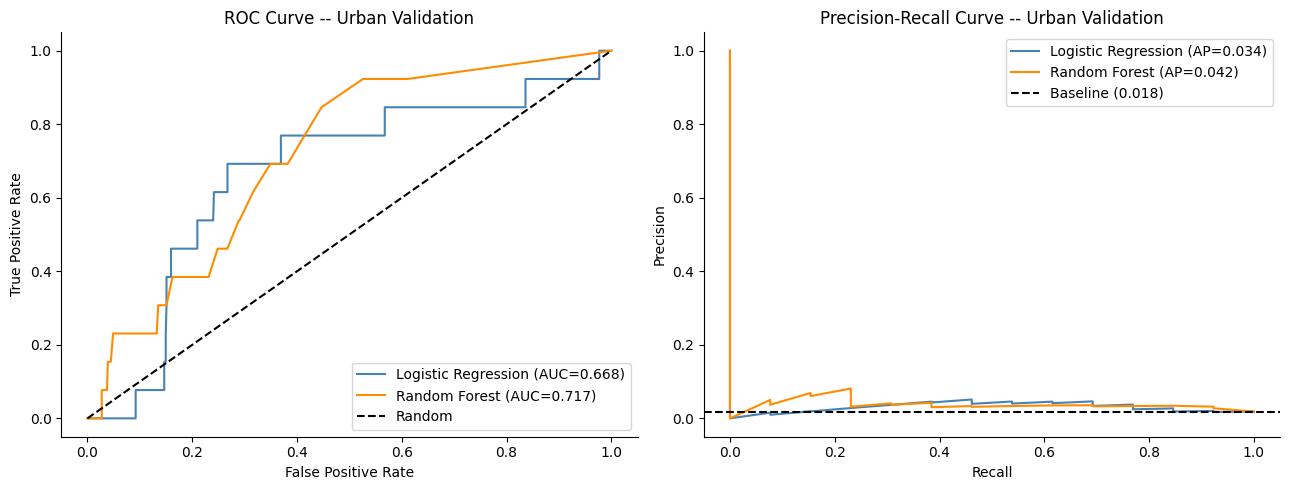

In [29]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_model = ['steelblue', 'darkorange']

for (name, r), color in zip(results.items(), colors_model):
    fpr, tpr, _ = roc_curve(y_val, r['proba'])
    auc = roc_auc_score(y_val, r['proba'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve -- Urban Validation')
axes[0].legend()
sns.despine(ax=axes[0])

for (name, r), color in zip(results.items(), colors_model):
    prec, rec, _ = precision_recall_curve(y_val, r['proba'])
    ap = average_precision_score(y_val, r['proba'])
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color)
axes[1].axhline(y_val.mean(), color='k', linestyle='--', label=f'Baseline ({y_val.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve -- Urban Validation')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('roc_pr_curves_urban.png', dpi=150)
plt.show()

In [30]:
def best_threshold(y_true, proba):
    prec, rec, thresholds = precision_recall_curve(y_true, proba)
    f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))
    idx = np.argmax(f1[:-1])
    return thresholds[idx], prec[idx], rec[idx], f1[idx]

print(f'{"Model":<25} {"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 65)
for name, r in results.items():
    t, p, rc, f = best_threshold(y_val, r['proba'])
    print(f'{name:<25} {t:>10.4f} {p:>10.4f} {rc:>8.4f} {f:>8.4f}')
    r['best_threshold'] = t

print('\n--- With recalibrated thresholds ---')
for name, r in results.items():
    preds_recal = (r['proba'] >= r['best_threshold']).astype(int)
    print(f'\n{name}:')
    print(classification_report(y_val, preds_recal, target_names=['non-fatal', 'fatal'], digits=3))

Model                      Threshold  Precision   Recall       F1
-----------------------------------------------------------------
Logistic Regression           0.6729     0.0513   0.4615   0.0923
Random Forest                 0.0860     0.0811   0.2308   0.1200

--- With recalibrated thresholds ---

Logistic Regression:
              precision    recall  f1-score   support

   non-fatal      0.988     0.841     0.908       696
       fatal      0.051     0.462     0.092        13

    accuracy                          0.834       709
   macro avg      0.520     0.651     0.500       709
weighted avg      0.971     0.834     0.893       709


Random Forest:
              precision    recall  f1-score   support

   non-fatal      0.985     0.951     0.968       696
       fatal      0.081     0.231     0.120        13

    accuracy                          0.938       709
   macro avg      0.533     0.591     0.544       709
weighted avg      0.969     0.938     0.952       709



/tmp/ipykernel_2886/3141336812.py:3: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))
/tmp/ipykernel_2886/3141336812.py:3: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))


## 7. Feature Importance (Random Forest)

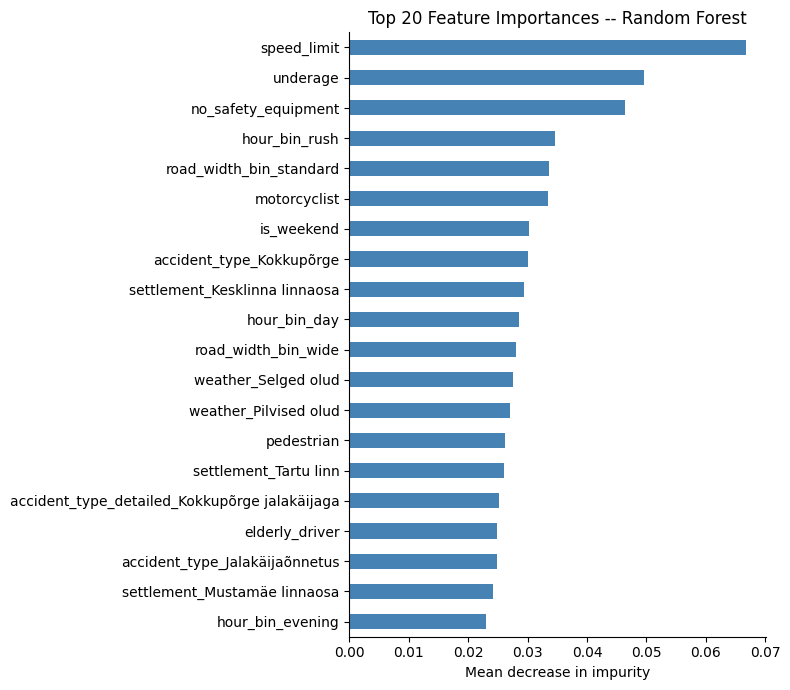

Top 20:
speed_limit                                     0.0668
underage                                        0.0496
no_safety_equipment                             0.0465
hour_bin_rush                                   0.0346
road_width_bin_standard                         0.0337
motorcyclist                                    0.0334
is_weekend                                      0.0302
accident_type_Kokkupõrge                        0.0301
settlement_Kesklinna linnaosa                   0.0293
hour_bin_day                                    0.0285
road_width_bin_wide                             0.0281
weather_Selged olud                             0.0275
weather_Pilvised olud                           0.0271
pedestrian                                      0.0262
settlement_Tartu linn                           0.0261
accident_type_detailed_Kokkupõrge jalakäijaga   0.0252
elderly_driver                                  0.0249
accident_type_Jalakäijaõnnetus                  0.0249
se

In [31]:
importances = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
      .sort_values(ascending=False)
)

top_n = 20
fig, ax = plt.subplots(figsize=(8, 7))
importances.head(top_n).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top {top_n} Feature Importances -- Random Forest')
ax.set_xlabel('Mean decrease in impurity')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print('Top 20:')
print(importances.head(top_n).round(4))

---

## Summary

| Model | ROC-AUC | PR-AUC | Notes |
|---|---|---|---|
| Logistic Regression | 0.6680 | 0.0336 | Final model |
| Random Forest | 0.7172 | 0.0415 | Probability collapse on fatal class |

*Fill in after running.*

**Final model: Logistic Regression** (`class_weight='balanced'`)
- Random Forest assigns near-identical probabilities to fatal and non-fatal cases (Fatal mean prob:     0.0345,
Non-fatal mean prob: 0.0195) -- unusable for ranking
- LR achieves better ROC-AUC, better recall, and is interpretable via coefficients

**Calibrated threshold from `best_threshold()`** -- carry this value to notebook 04.
Note: threshold optimised on urban val may not transfer to rural due to distribution shift.

**Next -> `04_evaluation.ipynb`:** retrain LR on full urban set, apply to rural test set, measure distribution shift.